# SSDC 2026 — Exploratory Data Analysis (EDA): Student Placement System Dataset by kata edward

## Bagian 0 — Setup & Sanity Check

In [327]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### 0.1 — Konfirmasi Shape

In [328]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = "../data/clean/"

company = pd.read_csv(
    DATA_DIR + "company_clean.csv",
    dtype={"id_company": str, "pic_phone": str},
    parse_dates=["created_at"],
)

status_student = pd.read_csv(
    DATA_DIR + "status_student_clean.csv",
    dtype={"id_status": str, "NIM": str, "no_whatsapp": str},
    parse_dates=["sync_date"],
)

student_all = pd.read_csv(
    DATA_DIR + "student_all_clean.csv", dtype={"NIM": str, "hp": str}
)

talent_request = pd.read_csv(
    DATA_DIR + "talent_request_clean.csv",
    dtype={"id_talent_req": str, "id_company": str, "no_whatsapp": str},
    parse_dates=["request_date"],
)

tracking_company = pd.read_csv(
    DATA_DIR + "tracking_company_clean.csv",
    dtype={
        "id_tracking_company": str,
        "id_talent_req": str,
        "id_company": str,
        "list_nim": str,
    },
    parse_dates=["request_date", "send_date"],
)

tracking_student = pd.read_csv(
    DATA_DIR + "tracking_student_clean.csv",
    dtype={"id_tracking_student": str, "NIM": str, "id_tracking_company": str},
    parse_dates=["last_update"],
)

tables = {
    "company": company,
    "talent_request": talent_request,
    "student_all": student_all,
    "status_student": status_student,
    "tracking_company": tracking_company,
    "tracking_student": tracking_student,
}

expected_shapes = {
    "company": 1500,
    "status_student": 25000,
    "student_all": 25000,
    "talent_request": 12000,
    "tracking_company": 12000,
    "tracking_student": 41600,
}

for name in tables:
    n = tables[name].shape[0]
    status = "MISMATCH"
    if n == expected_shapes[name]:
        status = "OK"
    print(
        f"{name:18s} shape={n}  expected_rows={expected_shapes.get(name):<6} [{status}]"
    )

company            shape=1500  expected_rows=1500   [OK]
talent_request     shape=12000  expected_rows=12000  [OK]
student_all        shape=25000  expected_rows=25000  [OK]
status_student     shape=25000  expected_rows=25000  [OK]
tracking_company   shape=12000  expected_rows=12000  [OK]
tracking_student   shape=41600  expected_rows=41600  [OK]


### 0.2 — Sanity Check Ringkas (PK, FK, tanggal)

In [329]:
pk_checks = {
    "company": "id_company",
    "status_student": "id_status",
    "student_all": "NIM",
    "talent_request": "id_talent_req",
    "tracking_company": "id_tracking_company",
    "tracking_student": "id_tracking_student",
}

print("-- Primary key unik -- ")
for name, pk in pk_checks.items():
    df = tables[name]
    dup = df[pk].duplicated().sum()
    print(f"{name:18s} PK={pk:20s} duplikat={dup} [{'OK' if dup==0 else 'ANOMALI'}]")


print("\n-- Foreign key yatim (orphan) --")

# fmt: off
orphan_ss_nim = ~status_student["NIM"].isin(student_all["NIM"])
orphan_tr_company = ~talent_request["id_company"].isin(company["id_company"])
orphan_tc_talent = ~tracking_company["id_talent_req"].isin(talent_request["id_talent_req"])
orphan_tc_company = ~tracking_company["id_company"].isin(company["id_company"])
orphan_ts_tc = ~tracking_student["id_tracking_company"].isin(tracking_company["id_tracking_company"])
orphan_ts_nim = ~tracking_student["NIM"].isin(student_all["NIM"])

print(f"status_student.NIM -> student_all.NIM : {orphan_ss_nim.sum()} yatim")
print(f"talent_request.id_company -> company.id_company : {orphan_tr_company.sum()} yatim")
print(f"tracking_company.id_talent_req -> talent_request.id_talent_req : {orphan_tc_talent.sum()} yatim")
print(f"tracking_company.id_company -> company.id_company : {orphan_tc_company.sum()} yatim")
print(f"tracking_student.id_tracking_company -> tracking_company.id_tracking_company : {orphan_ts_tc.sum()} yatim")
print(f"tracking_student.NIM -> student_all.NIM : {orphan_ts_nim.sum()} yatim")
# fmt: on


print("\n-- Draft tracking_company (expected 598) --")
draft_mask = tracking_company["send_date"].isna() & tracking_company["list_nim"].isna()
print(f"Baris tanpa send_date & list_nim: {draft_mask.sum()}")
print(tracking_company.loc[draft_mask, "progress"].value_counts())


print("\n-- Rentang tanggal --")
date_cols = {
    "company.created_at": company["created_at"],
    "talent_request.request_date": talent_request["request_date"],
    "status_student.sync_date": status_student["sync_date"],
    "tracking_company.request_date": tracking_company["request_date"],
    "tracking_company.send_date": tracking_company["send_date"],
    "tracking_student.last_update": tracking_student["last_update"],
}

for label, col in date_cols.items():
    print(f"{label:30s} min={col.min().date()}  max={col.max().date()}")

sent = tracking_company.dropna(subset=["send_date"])
invalid_order = (sent["send_date"] < sent["request_date"]).sum()
print(f"\ntracking_company.send_date < tracking_company.request_date (harus 0): {invalid_order}")  # fmt: skip

-- Primary key unik -- 
company            PK=id_company           duplikat=0 [OK]
status_student     PK=id_status            duplikat=0 [OK]
student_all        PK=NIM                  duplikat=0 [OK]
talent_request     PK=id_talent_req        duplikat=0 [OK]
tracking_company   PK=id_tracking_company  duplikat=0 [OK]
tracking_student   PK=id_tracking_student  duplikat=0 [OK]

-- Foreign key yatim (orphan) --
status_student.NIM -> student_all.NIM : 0 yatim
talent_request.id_company -> company.id_company : 0 yatim
tracking_company.id_talent_req -> talent_request.id_talent_req : 0 yatim
tracking_company.id_company -> company.id_company : 0 yatim
tracking_student.id_tracking_company -> tracking_company.id_tracking_company : 0 yatim
tracking_student.NIM -> student_all.NIM : 0 yatim

-- Draft tracking_company (expected 598) --
Baris tanpa send_date & list_nim: 598
progress
Draft    598
Name: count, dtype: int64

-- Rentang tanggal --
company.created_at             min=2022-01-02  max=2024-12

### 0.2b — Cross-check STUDENT ALL ↔ STATUS STUDENT (BT-08)

In [330]:
merged = student_all.merge(
    status_student[["NIM", "nama", "program_studi", "semester"]],
    on="NIM",
    how="outer",
    suffixes=("_studentall", "_status"),
    indicator=True,
)

# fmt: off
orphan_left = (merged['_merge'] == 'left_only').sum()   # ada di student_all, tidak di status_student
orphan_right = (merged['_merge'] == 'right_only').sum() # ada di status_student, tidak di student_all
print(f"NIM hanya di student_all (orphan)   : {orphan_left}")
print(f"NIM hanya di status_student (orphan): {orphan_right}")

both = merged[merged['_merge'] == 'both'].copy()
mismatch_nama = (both['nama_studentall'] != both['nama_status']).sum()
mismatch_prodi = (both['program_studi_studentall'] != both['program_studi_status']).sum()
mismatch_semester = (both['semester_studentall'] != both['semester_status']).sum()

print(f"\nDari {len(both)} NIM yang match di kedua tabel:")
print(f"  mismatch nama         : {mismatch_nama}")
print(f"  mismatch program_studi: {mismatch_prodi}")
print(f"  mismatch semester     : {mismatch_semester}")

kesimpulan = "SINKRON 100%" if (orphan_left + orphan_right + mismatch_nama + mismatch_prodi + mismatch_semester) == 0 else "ADA ANOMALI"
print(f"\n>>> Kesimpulan 0.2b: {kesimpulan}")
# fmt: on

NIM hanya di student_all (orphan)   : 0
NIM hanya di status_student (orphan): 0

Dari 25000 NIM yang match di kedua tabel:
  mismatch nama         : 0
  mismatch program_studi: 0
  mismatch semester     : 0

>>> Kesimpulan 0.2b: SINKRON 100%


## Bagian 1 — Profil Dasar Tiap Tabel → H1

In [331]:
def bar_with_labels(ax, series, title, rotation=0, palette="Set1"):
    sns.barplot(
        x=series.index.astype(str),
        y=series.values,
        hue=series.index.astype(str),
        palette=palette,
        legend=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=rotation)
    ax.set_ylim(0, series.max() * 1.15)
    ax.margins(x=0.05)
    for container in ax.containers:
        ax.bar_label(container, padding=3)


def hist_with_labels(ax, data, title, bins=20, color=None):
    sns.histplot(data, bins=bins, ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel("")

    max_bin_height = max(v for container in ax.containers for v in container.datavalues)
    ax.set_ylim(0, max_bin_height * 1.15)

    for container in ax.containers:
        labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
        ax.bar_label(container, labels=labels, padding=3, fontsize=8)


def print_summary(label, counts, unit="perusahaan"):
    print(f"{label}:")
    print(f"   dominan : {counts.idxmax()} ({counts.max()} {unit})")
    print(f"   sedikit : {counts.idxmin()} ({counts.min()} {unit})")
    print()

### 1.1 — Profil company

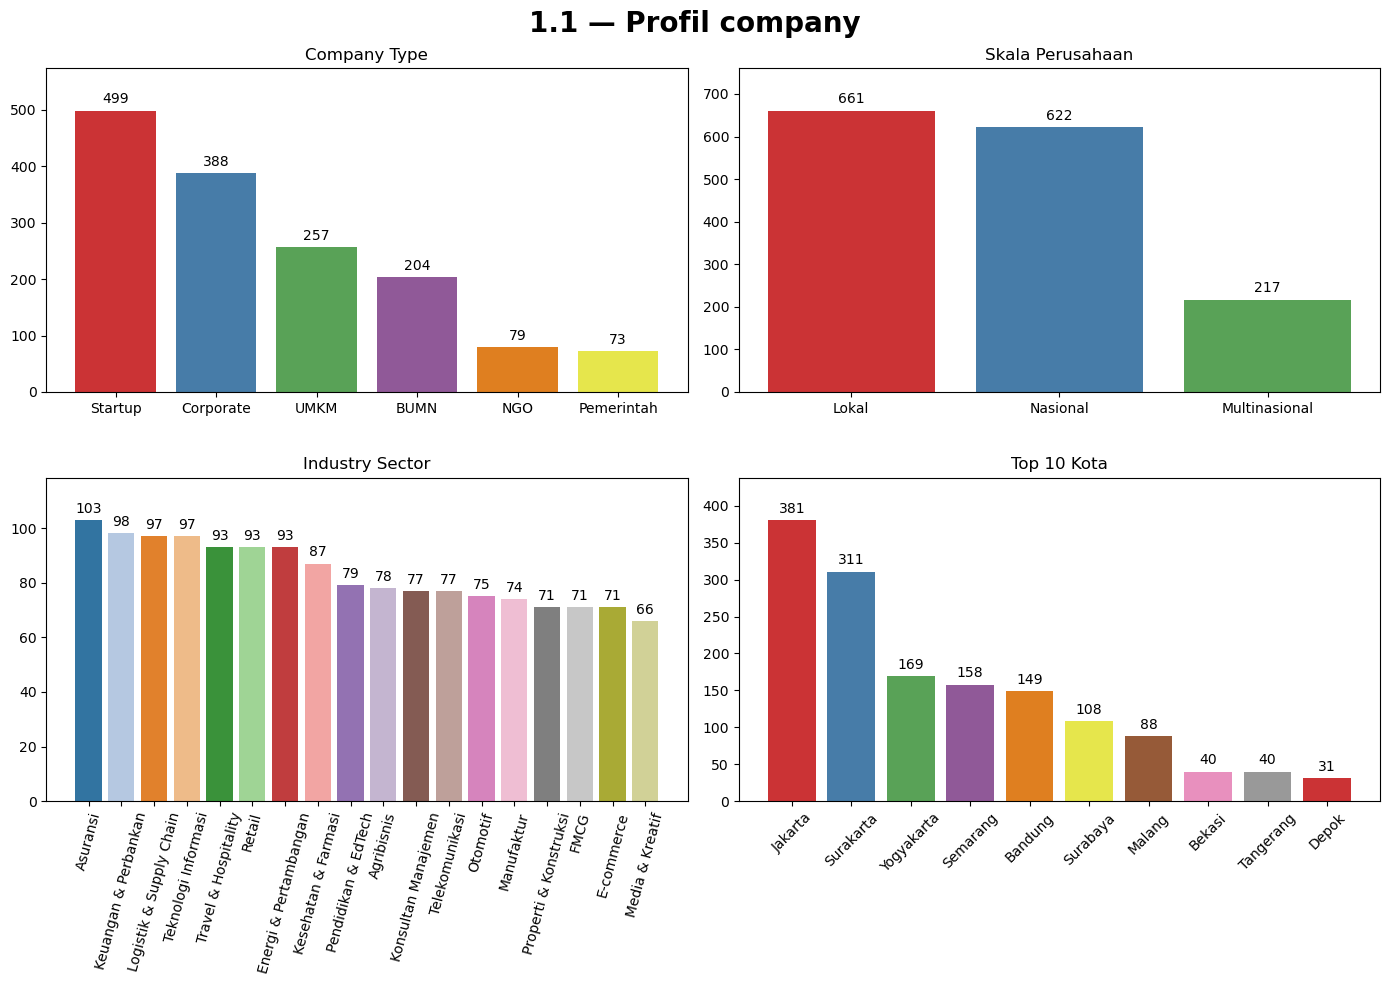

company_type:
   dominan : Startup (499 perusahaan)
   sedikit : Pemerintah (73 perusahaan)

skala_perusahaan:
   dominan : Lokal (661 perusahaan)
   sedikit : Multinasional (217 perusahaan)

industry_sector:
   dominan : Asuransi (103 perusahaan)
   sedikit : Media & Kreatif (66 perusahaan)

kota:
   dominan : Jakarta (381 perusahaan)
   sedikit : Bogor (25 perusahaan)

jumlah kota unik: 11
daftar lengkap per kota:
   Jakarta        : 381 perusahaan
   Surakarta      : 311 perusahaan
   Yogyakarta     : 169 perusahaan
   Semarang       : 158 perusahaan
   Bandung        : 149 perusahaan
   Surabaya       : 108 perusahaan
   Malang         : 88 perusahaan
   Bekasi         : 40 perusahaan
   Tangerang      : 40 perusahaan
   Depok          : 31 perusahaan
   Bogor          : 25 perusahaan


In [332]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("1.1 — Profil company", fontsize=20, fontweight="bold")


# fmt: off
bar_with_labels(axes[0, 0], company["company_type"].value_counts(), "Company Type")
bar_with_labels(axes[0, 1], company["skala_perusahaan"].value_counts(), "Skala Perusahaan")
bar_with_labels(axes[1, 0], company["industry_sector"].value_counts(), "Industry Sector", rotation=75, palette="tab20")
bar_with_labels(axes[1, 1], company["kota"].value_counts().head(10), "Top 10 Kota", rotation=45)
# fmt: on

plt.tight_layout(h_pad=3)
plt.show()


company_type_counts = company["company_type"].value_counts()
skala_counts = company["skala_perusahaan"].value_counts()
sector_counts = company["industry_sector"].value_counts()
kota_counts = company["kota"].value_counts()

print_summary("company_type", company_type_counts)
print_summary("skala_perusahaan", skala_counts)
print_summary("industry_sector", sector_counts)
print_summary("kota", kota_counts)

print(f"jumlah kota unik: {company['kota'].nunique()}")
print("daftar lengkap per kota:")
for kota, jumlah in kota_counts.items():
    print(f"   {kota:15s}: {jumlah} perusahaan")

### 1.2 - Profil talent_request

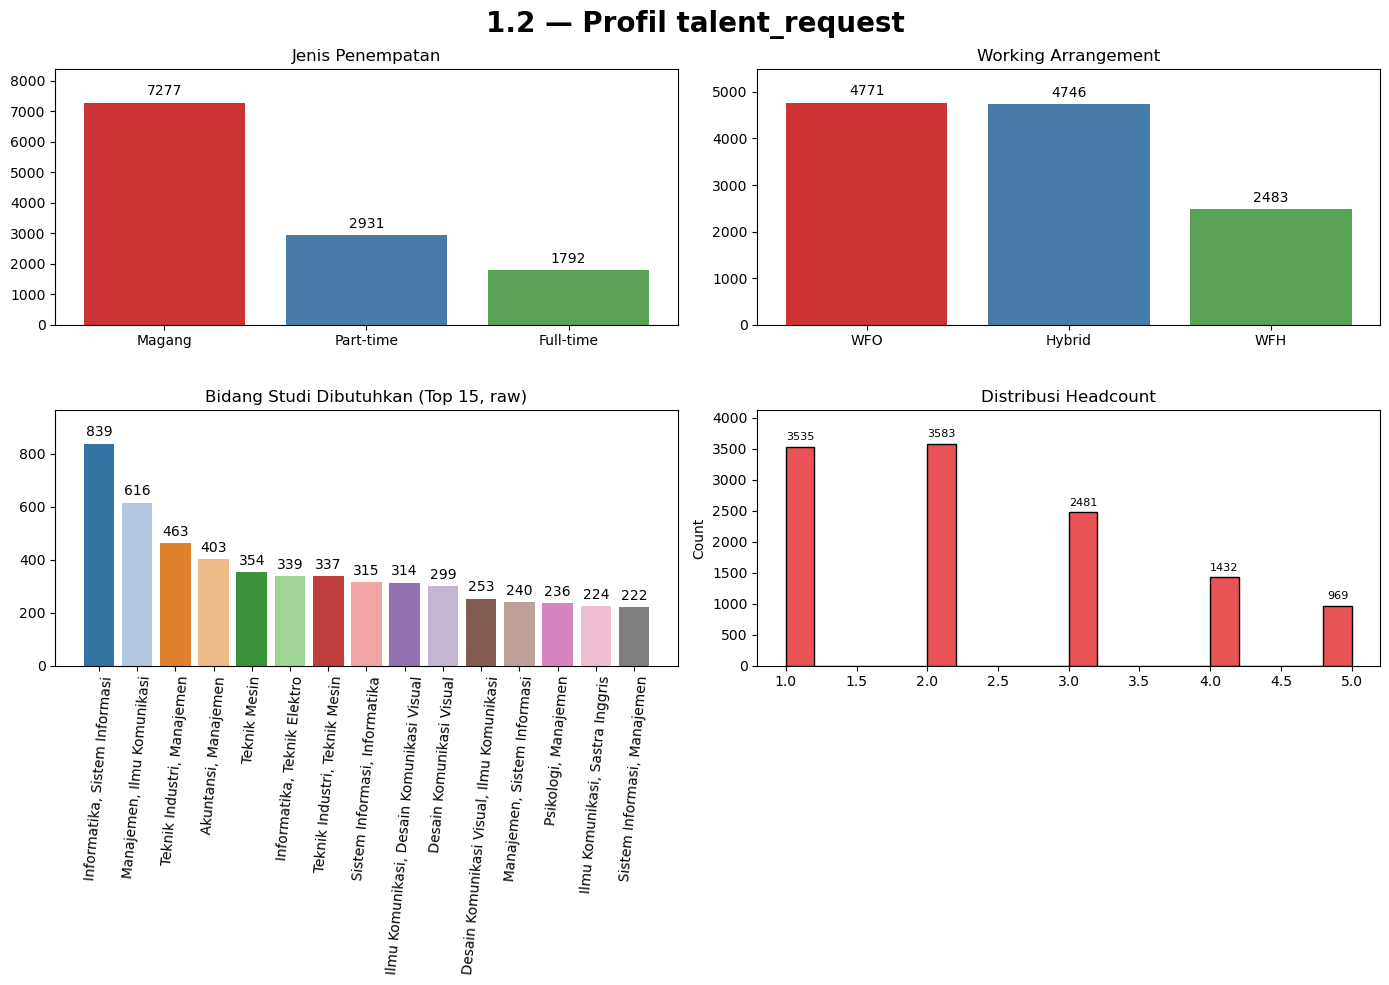

jenis_penempatan:
   dominan : Magang (7277 perusahaan)
   sedikit : Full-time (1792 perusahaan)

working_arrangement:
   dominan : WFO (4771 perusahaan)
   sedikit : WFH (2483 perusahaan)

bidang_studi_dibutuhkan: 113 kombinasi unik (raw, belum di-explode)
   dominan : Informatika, Sistem Informasi (839 request)
   catatan : analisis 'bidang paling jarang' lebih valid setelah explode (bagian supply-demand)

headcount describe():
count    12000.000000
mean         2.393083
std          1.245404
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: headcount, dtype: float64


In [333]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("1.2 — Profil talent_request", fontsize=20, fontweight="bold")

bidang_studi_counts_full = talent_request["bidang_studi_dibutuhkan"].value_counts()

# fmt: off
bar_with_labels(axes[0, 0], talent_request["jenis_penempatan"].value_counts(), "Jenis Penempatan")
bar_with_labels(axes[0, 1], talent_request["working_arrangement"].value_counts(), "Working Arrangement")
bar_with_labels(axes[1, 0], bidang_studi_counts_full.head(15), "Bidang Studi Dibutuhkan (Top 15, raw)", rotation=85, palette="tab20")
hist_with_labels(axes[1, 1], talent_request["headcount"], "Distribusi Headcount", bins=20, color=sns.color_palette("Set1")[0])

plt.tight_layout(h_pad=3)
plt.show()

print_summary("jenis_penempatan", talent_request["jenis_penempatan"].value_counts())
print_summary("working_arrangement", talent_request["working_arrangement"].value_counts())

print(f"bidang_studi_dibutuhkan: {len(bidang_studi_counts_full)} kombinasi unik (raw, belum di-explode)")
print(f"   dominan : {bidang_studi_counts_full.idxmax()} ({bidang_studi_counts_full.max()} request)")
print(f"   catatan : analisis 'bidang paling jarang' lebih valid setelah explode (bagian supply-demand)")
print()
# fmt: on

print("headcount describe():")
print(talent_request["headcount"].describe())

### 1.3 - Profil student_all

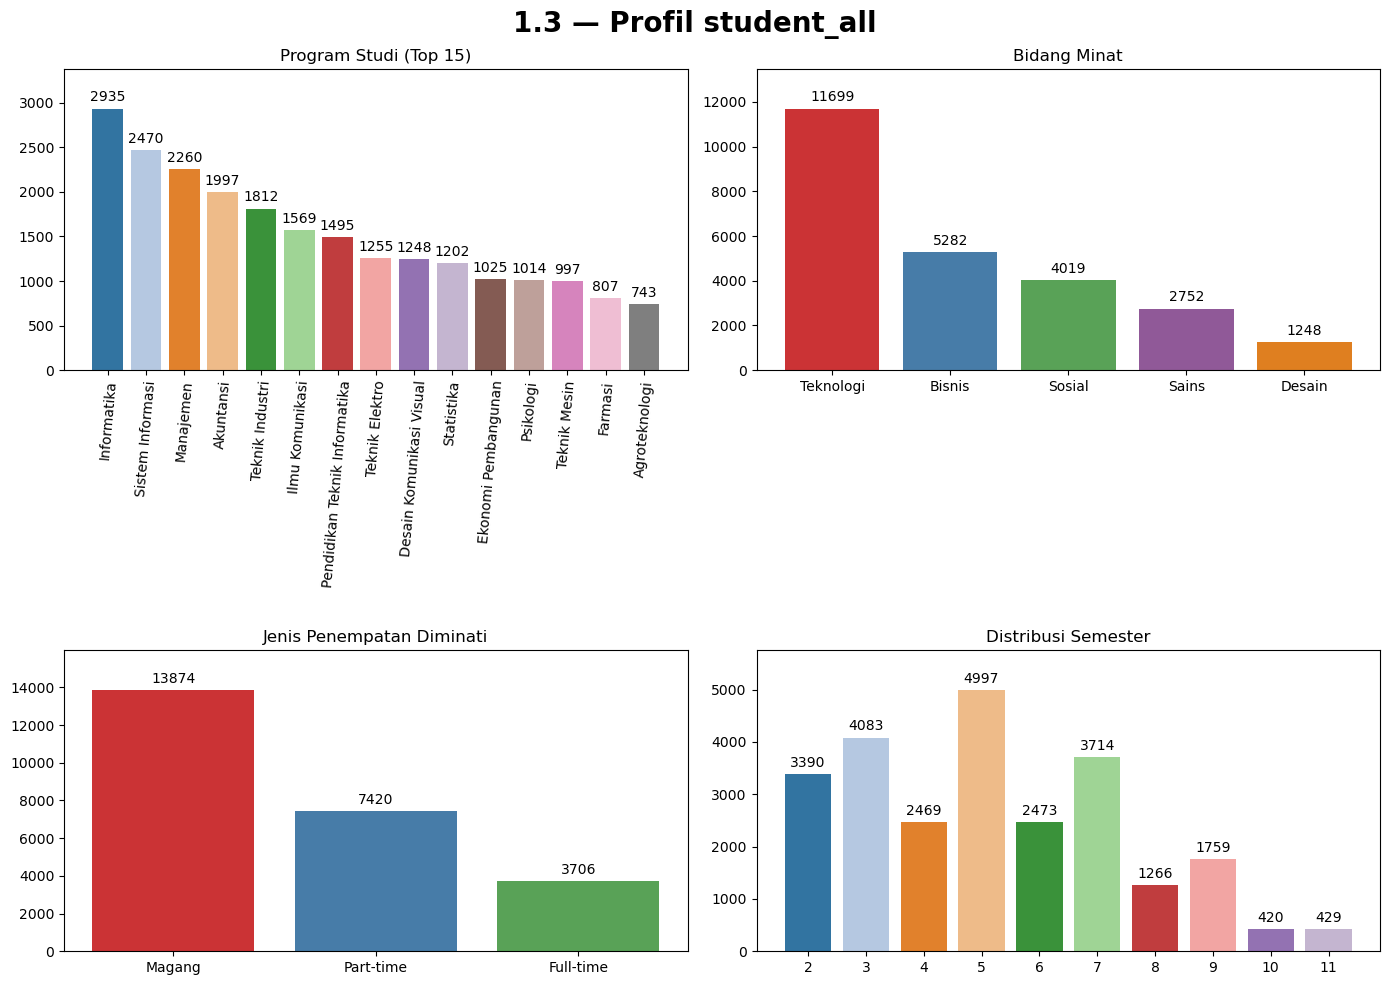

program_studi: 18 prodi unik
   terbesar : Informatika (2935 mahasiswa)
   terkecil : Ilmu Hukum (700 mahasiswa)

bidang_minat:
   dominan : Teknologi (11699 mahasiswa)
   sedikit : Desain (1248 mahasiswa)

jenis_penempatan_diminati:
   dominan : Magang (13874 mahasiswa)
   sedikit : Full-time (3706 mahasiswa)

Distribusi semester (urut semester, bukan frekuensi):
   semester  2: 3390 mahasiswa
   semester  3: 4083 mahasiswa
   semester  4: 2469 mahasiswa
   semester  5: 4997 mahasiswa
   semester  6: 2473 mahasiswa
   semester  7: 3714 mahasiswa
   semester  8: 1266 mahasiswa
   semester  9: 1759 mahasiswa
   semester 10: 420 mahasiswa
   semester 11: 429 mahasiswa


In [334]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("1.3 — Profil student_all", fontsize=20, fontweight="bold")

program_studi_counts_full = student_all["program_studi"].value_counts()
semester_counts = student_all["semester"].value_counts().sort_index()

# fmt:off
bar_with_labels(axes[0, 0], program_studi_counts_full.head(15), "Program Studi (Top 15)", rotation=85, palette="tab20")
bar_with_labels(axes[0, 1], student_all["bidang_minat"].value_counts(), "Bidang Minat")
bar_with_labels(axes[1, 0], student_all["jenis_penempatan_diminati"].value_counts(), "Jenis Penempatan Diminati")
bar_with_labels(axes[1, 1], semester_counts, "Distribusi Semester", palette="tab20")

plt.tight_layout(h_pad=3)
plt.show()

print(f"program_studi: {len(program_studi_counts_full)} prodi unik")
print(f"   terbesar : {program_studi_counts_full.idxmax()} ({program_studi_counts_full.max()} mahasiswa)")
print(f"   terkecil : {program_studi_counts_full.idxmin()} ({program_studi_counts_full.min()} mahasiswa)")
print()

print_summary("bidang_minat", student_all["bidang_minat"].value_counts(), unit="mahasiswa")
print_summary("jenis_penempatan_diminati", student_all["jenis_penempatan_diminati"].value_counts(), unit="mahasiswa")
# fmt:on

print("Distribusi semester (urut semester, bukan frekuensi):")
for sem, jumlah in semester_counts.items():
    print(f"   semester {sem:2d}: {jumlah} mahasiswa")

### 1.4 - Profil status_student

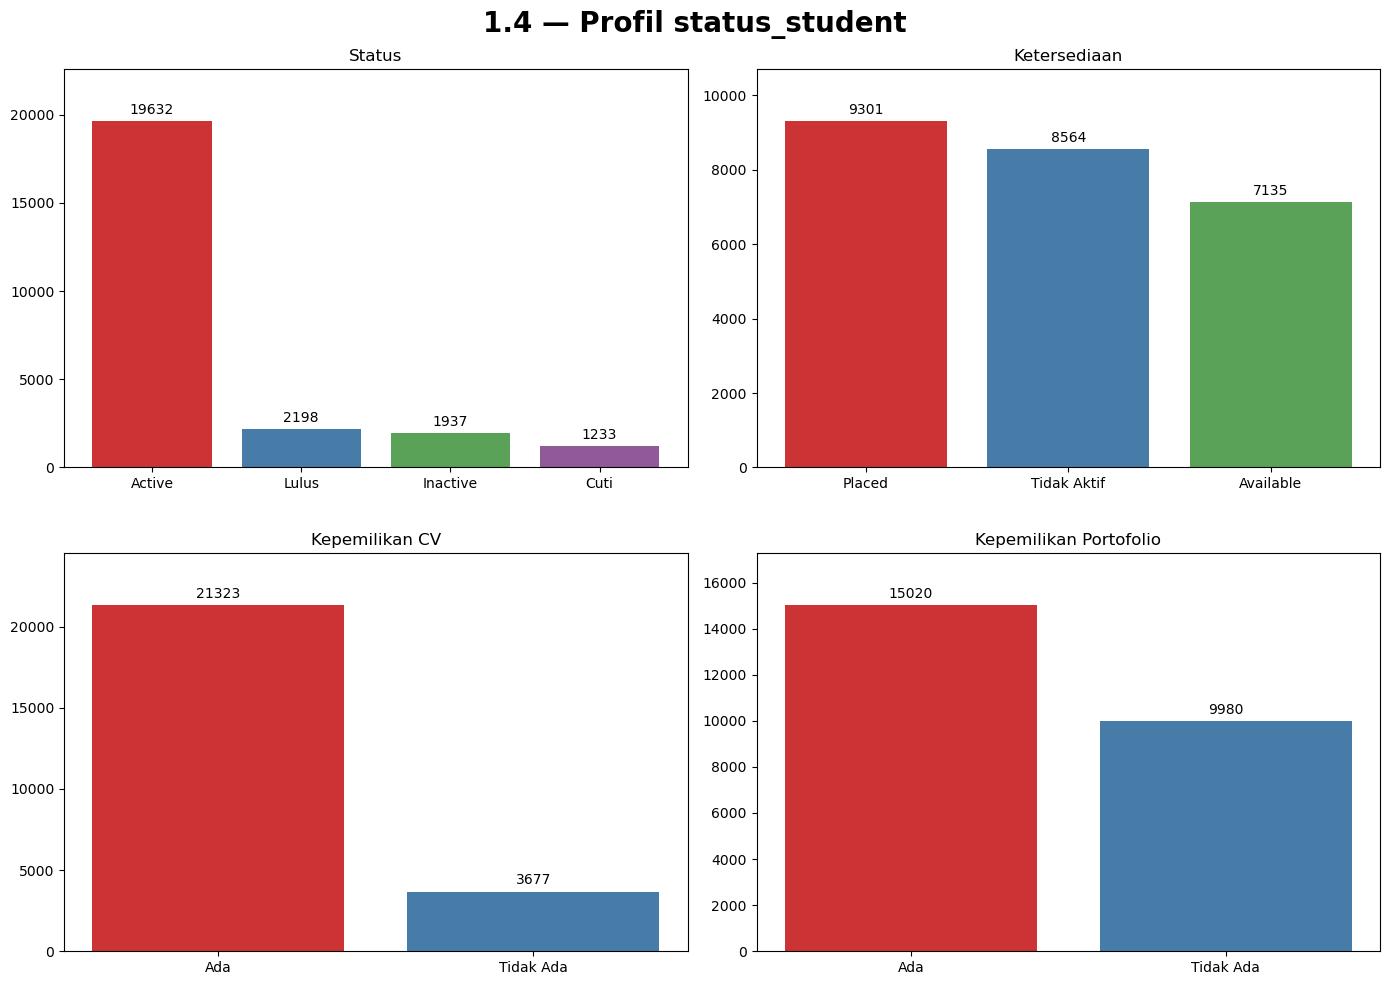

status:
   dominan : Active (19632 mahasiswa)
   sedikit : Cuti (1233 mahasiswa)

ketersediaan:
   dominan : Placed (9301 mahasiswa)
   sedikit : Available (7135 mahasiswa)

CV:
   dominan : Ada (21323 mahasiswa)
   sedikit : Tidak Ada (3677 mahasiswa)

portofolio:
   dominan : Ada (15020 mahasiswa)
   sedikit : Tidak Ada (9980 mahasiswa)



In [335]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("1.4 — Profil status_student", fontsize=20, fontweight="bold")

# fmt:off
bar_with_labels(axes[0, 0], status_student["status"].value_counts(), "Status")
bar_with_labels(axes[0, 1], status_student["ketersediaan"].value_counts(), "Ketersediaan")
bar_with_labels(axes[1, 0], status_student["CV"].value_counts(), "Kepemilikan CV")
bar_with_labels(axes[1, 1], status_student["portofolio"].value_counts(), "Kepemilikan Portofolio")

plt.tight_layout(h_pad=3)
plt.show()

print_summary("status", status_student["status"].value_counts(), unit="mahasiswa")
print_summary("ketersediaan", status_student["ketersediaan"].value_counts(), unit="mahasiswa")
print_summary("CV", status_student["CV"].value_counts(), unit="mahasiswa")
print_summary("portofolio", status_student["portofolio"].value_counts(), unit="mahasiswa")
# fmt:on

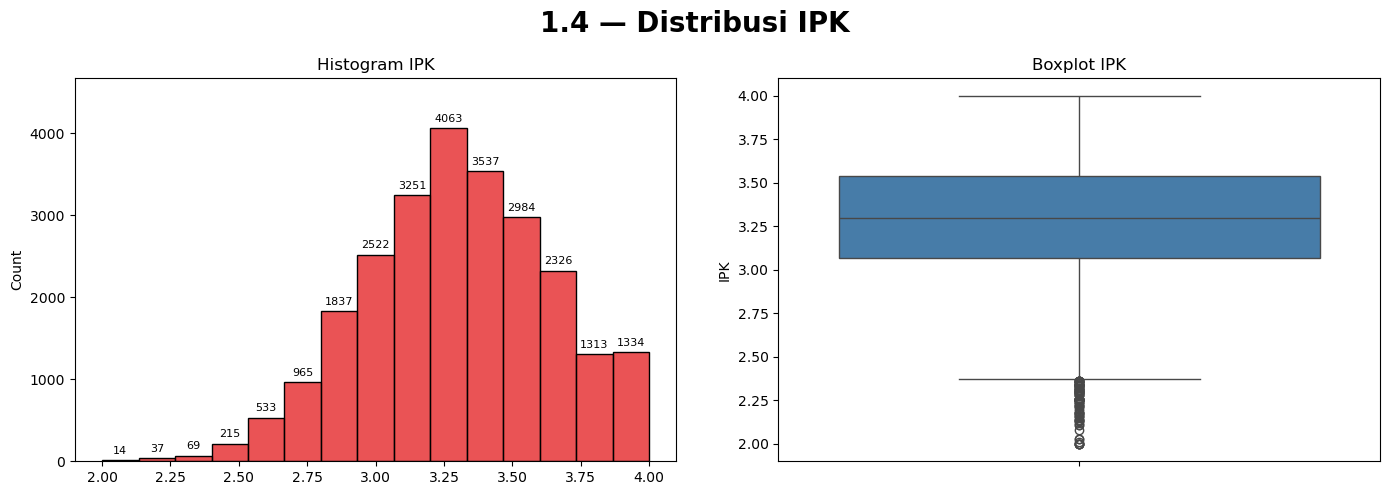

IPK describe():
count    25000.000000
mean         3.298299
std          0.341807
min          2.000000
25%          3.070000
50%          3.300000
75%          3.540000
max          4.000000
Name: IPK, dtype: float64

Breakdown per rentang IPK (bin 0.2):
   (1.999, 2.2] : 28 mahasiswa
   (2.2, 2.4] : 97 mahasiswa
   (2.4, 2.6] : 442 mahasiswa
   (2.6, 2.8] : 1370 mahasiswa
   (2.8, 3.0] : 2959 mahasiswa
   (3.0, 3.2] : 4840 mahasiswa
   (3.2, 3.4] : 5752 mahasiswa
   (3.4, 3.6] : 4708 mahasiswa
   (3.6, 3.8] : 2965 mahasiswa
   (3.8, 4.0] : 1839 mahasiswa


In [336]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("1.4 — Distribusi IPK", fontsize=20, fontweight="bold")

hist_with_labels(
    axes[0],
    status_student["IPK"],
    "Histogram IPK",
    bins=15,
    color=sns.color_palette("Set1")[0],
)

sns.boxplot(y=status_student["IPK"], ax=axes[1], color=sns.color_palette("Set1")[1])
axes[1].set_title("Boxplot IPK")

plt.tight_layout(w_pad=3)
plt.show()

print("IPK describe():")
print(status_student["IPK"].describe())

print("\nBreakdown per rentang IPK (bin 0.2):")
bin_edges = np.arange(2.0, 4.01, 0.2)
ipk_binned = pd.cut(status_student["IPK"], bins=bin_edges, include_lowest=True)
for interval, jumlah in ipk_binned.value_counts().sort_index().items():
    print(f"   {interval} : {jumlah} mahasiswa")

### 1.5 - Rentang tanggal semua tabel

In [337]:
date_summary = pd.DataFrame(
    {
        "tabel.kolom": [
            "company.created_at",
            "talent_request.request_date",
            "status_student.sync_date",
            "tracking_company.request_date",
            "tracking_company.send_date",
            "tracking_student.last_update",
        ],
        "min": [
            company["created_at"].min(),
            talent_request["request_date"].min(),
            status_student["sync_date"].min(),
            tracking_company["request_date"].min(),
            tracking_company["send_date"].min(),
            tracking_student["last_update"].min(),
        ],
        "max": [
            company["created_at"].max(),
            talent_request["request_date"].max(),
            status_student["sync_date"].max(),
            tracking_company["request_date"].max(),
            tracking_company["send_date"].max(),
            tracking_student["last_update"].max(),
        ],
    }
)

date_summary["rentang_hari"] = (date_summary["max"] - date_summary["min"]).dt.days

date_summary

,tabel.kolom,min,max,rentang_hari
0,company.created_at,2022-01-02,2024-12-31,1094
1,talent_request.request_date,2023-02-01,2025-01-31,730
2,status_student.sync_date,2023-02-01,2025-01-31,730
3,tracking_company.request_date,2023-02-01,2025-01-31,730
4,tracking_company.send_date,2023-02-04,2025-02-21,748
5,tracking_student.last_update,2023-02-08,2025-05-17,829
